In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn streamlit joblib


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [10]:


df = pd.read_csv("heart_disease_uci.csv")



In [3]:
import os
os.getcwd()

'/home/e0178478-631a-4aad-90c4-d2c27d1c7ff2'

In [9]:
import os
os.listdir()

['.gitconfig',
 'Untitled3.ipynb',
 '.config',
 'heart_disease_uci.csv',
 '.pythonstartup.py',
 'Untitled.ipynb',
 '.cache',
 '.anaconda',
 'Untitled5.ipynb',
 '.vimrc',
 'README.ipynb',
 '.profile',
 '.ipython',
 '.jupyter',
 '.bashrc',
 'Untitled2.ipynb',
 'Untitled8.ipynb',
 '.ipynb_checkpoints',
 'Untitled1.ipynb',
 'anaconda_projects',
 '.npm',
 '.local',
 'Untitled4.ipynb',
 '.conda',
 'Untitled6.ipynb',
 '.virtualenvs',
 'Untitled7.ipynb']

In [11]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [16]:
df.info()
df.describe()
df["target"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
 16  target    920 non-null    int64  
dtypes: float64(5), int64(4), object(8)
memory usage: 122.3+ KB


1    509
0    411
Name: target, dtype: int64

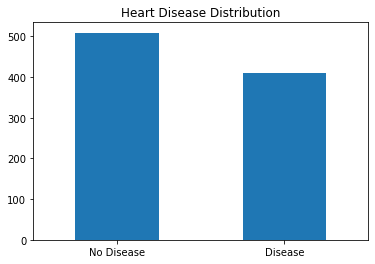

In [15]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xticks([0,1], ["No Disease", "Disease"], rotation=0)
plt.show()

In [14]:
df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

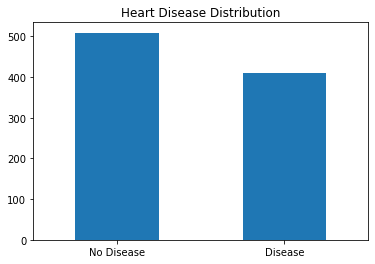

In [17]:
import matplotlib.pyplot as plt

df["target"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xticks([0,1], ["No Disease", "Disease"], rotation=0)
plt.show()

In [18]:
df = df.drop(["id", "dataset", "num"], axis=1)


In [19]:
df.isnull().sum()

age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

In [20]:
df = df.dropna()

In [21]:
print(df.head())
print(df["target"].value_counts())

   age     sex               cp  trestbps   chol    fbs         restecg  \
0   63    Male   typical angina     145.0  233.0   True  lv hypertrophy   
1   67    Male     asymptomatic     160.0  286.0  False  lv hypertrophy   
2   67    Male     asymptomatic     120.0  229.0  False  lv hypertrophy   
3   37    Male      non-anginal     130.0  250.0  False          normal   
4   41  Female  atypical angina     130.0  204.0  False  lv hypertrophy   

   thalch  exang  oldpeak        slope   ca               thal  target  
0   150.0  False      2.3  downsloping  0.0       fixed defect       0  
1   108.0   True      1.5         flat  3.0             normal       1  
2   129.0   True      2.6         flat  2.0  reversable defect       1  
3   187.0  False      3.5  downsloping  0.0             normal       0  
4   172.0  False      1.4    upsloping  0.0             normal       0  
0    160
1    139
Name: target, dtype: int64


In [27]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("heart_disease_uci.csv")

# -------------------------------
# 2. CREATE TARGET (IMPORTANT)
# -------------------------------
# num: 0 = no disease, 1-4 = disease
df["target"] = df["num"].apply(lambda x: 1 if x > 0 else 0)

# -------------------------------
# 3. DROP USELESS COLUMNS
# -------------------------------
df = df.drop(["id", "dataset", "num"], axis=1)

# -------------------------------
# 4. HANDLE MISSING VALUES
# -------------------------------
df = df.dropna()

# -------------------------------
# 5. SEPARATE FEATURES & TARGET
# -------------------------------
X = df.drop("target", axis=1)
y = df["target"]

# -------------------------------
# 6. HANDLE CATEGORICAL DATA
# -------------------------------
X = pd.get_dummies(X, drop_first=True)

print("Final feature shape:", X.shape)  # Debug check

# -------------------------------
# 7. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 8. FEATURE SCALING
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# 9. MODEL TRAINING
# -------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 10. PREDICTIONS
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 11. EVALUATION
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# -------------------------------
# 12. SAVE MODEL & SCALER
# -------------------------------
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("\n✅ Model and scaler saved successfully!")

Final feature shape: (299, 18)
Accuracy: 0.8666666666666667

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.86      0.88        35
           1       0.81      0.88      0.85        25

    accuracy                           0.87        60
   macro avg       0.86      0.87      0.86        60
weighted avg       0.87      0.87      0.87        60


✅ Model and scaler saved successfully!


In [26]:
print(df.dtypes)

age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object
